In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cloelite.input import reader
from cloelite.cosmology import camb_cosmology
from cloelite.observables import spectro
from copy import deepcopy

import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)

plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [2]:
def transform_dict(dictionary):
    dictionary_new = deepcopy(dictionary)
    if dictionary_new['As']<1e-7: dictionary_new['As'] *= 1e9
    if 'H0' in dictionary_new.keys(): dictionary_new['h'] = dictionary_new.pop('H0') / 100.0
    if 'omch2' in dictionary_new.keys(): dictionary_new['wc'] = dictionary_new.pop('omch2')
    if 'ombh2' in dictionary_new.keys(): dictionary_new['wb'] = dictionary_new.pop('ombh2')
    return dictionary_new

In [3]:
params_reader = reader.ParamsReader('../../cloelite/input/parameters.yaml')
H0 = params_reader.get_section('cosmology')['H0']
h = H0 / 100.0
ombh2 = params_reader.get_section('cosmology')['ombh2']
omch2 = params_reader.get_section('cosmology')['omch2']
ns = params_reader.get_section('cosmology')['ns']
As = params_reader.get_section('cosmology')['As']
background = camb_cosmology.CAMBBackground(H0=H0, ombh2=ombh2, omch2=omch2, ns=ns, As=As, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
linear_perturbations = camb_cosmology.CAMBLinearPerturbations(background=background, redshifts=np.linspace(0.0, 4.0, 256))
background_fiducial = camb_cosmology.CAMBBackground(H0=H0, ombh2=ombh2, omch2=omch2*1.1, ns=ns, As=As, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
mps_spectro = spectro.LegendreMultipolesComet(linear_perturbations=linear_perturbations, background_fiducial=background_fiducial)
mps_spectro.set_number_density(nbar=1e-4)

Note: redshifts have been re-sorted (earliest first)


In [4]:
k = np.logspace(-3, np.log10(0.3), 100)
parameters = params_reader.get_section('cosmology') | params_reader.get_section('GCsp.theory', 0) | params_reader.get_section('GCsp.systematics', 0)
parameters['z'] = 1.0

parameters_comet = transform_dict(parameters)
parameters_comet_fid = deepcopy(parameters_comet)
parameters_comet_fid['wc'] = parameters_comet['wc'] * 1.1
mps_spectro.set_fiducial_cosmology_comet(parameters_comet_fid)
mps_spectro.comet_inst.define_nbar(nbar=1e-4)
mps = mps_spectro.power_multipoles_comet(k=k, parameters=parameters_comet)

In [5]:
mps_1 = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])

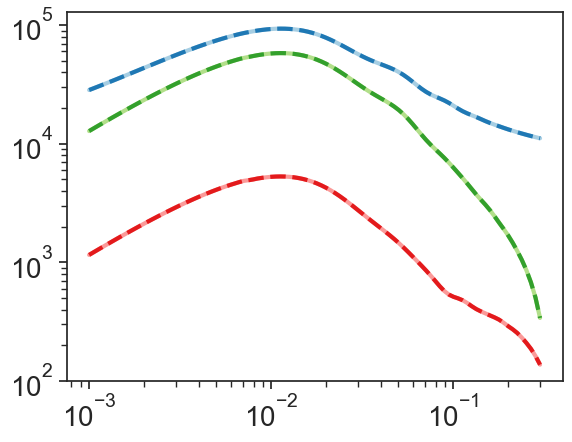

In [6]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

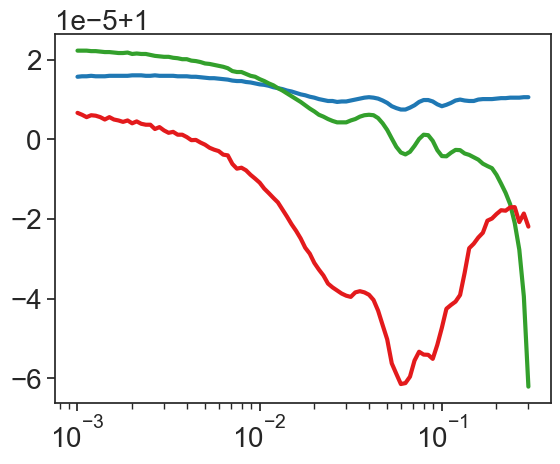

In [7]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [8]:
parameters['As'] = 1e-9
parameters_comet = transform_dict(parameters)
mps = mps_spectro.power_multipoles_comet(k=k, parameters=parameters_comet)
print ('-----')
mps_1 = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])

-----


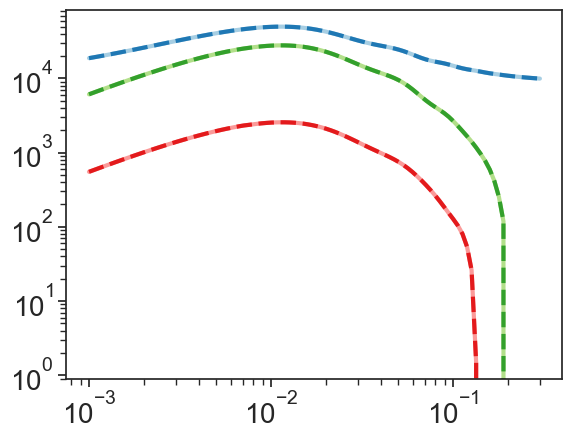

In [9]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

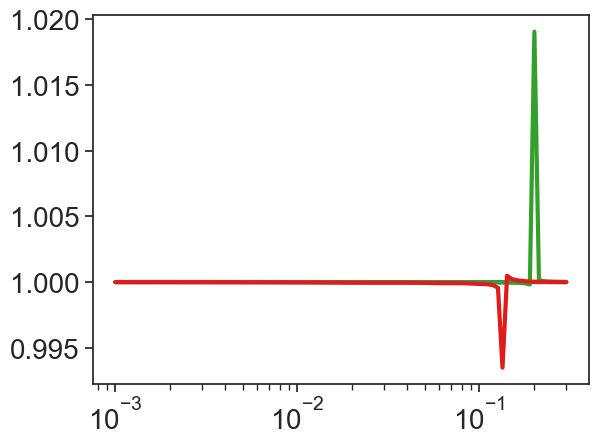

In [10]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [11]:
parameters['As'] = 2.1e-9
parameters['H0'] = 90.0
parameters_comet = transform_dict(parameters)
mps = mps_spectro.power_multipoles_comet(k=k, parameters=parameters_comet)
print ('-------')
mps_1 = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])

-------


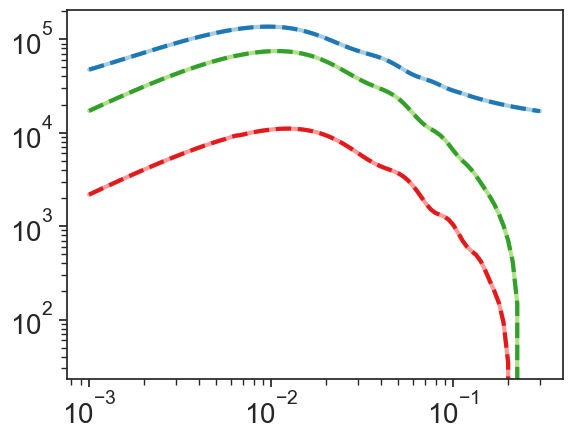

In [12]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

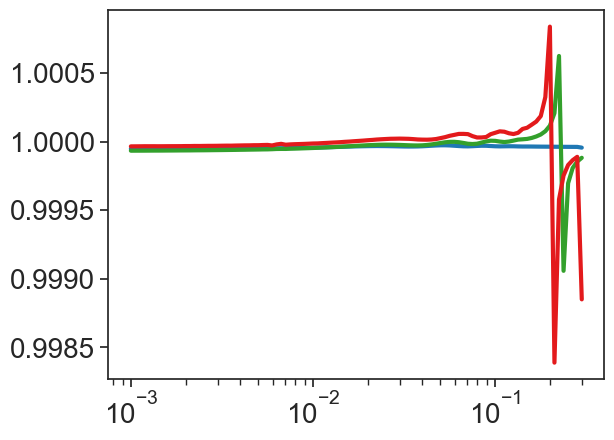

In [13]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [14]:
parameters['H0'] = 69.5
parameters['omch2'] = 0.15
parameters_comet = transform_dict(parameters)
mps = mps_spectro.power_multipoles_comet(k=k, parameters=parameters_comet)
print ('-------')
mps_1 = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])

-------


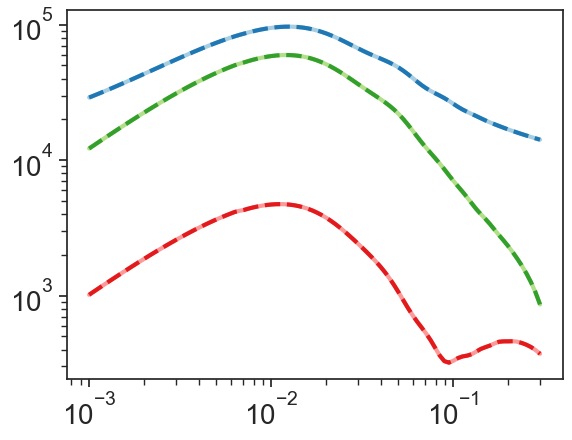

In [15]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

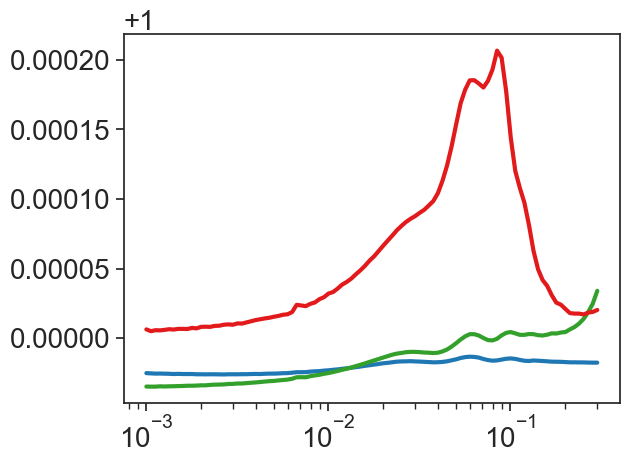

In [16]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [17]:
data_reader = reader.DataReader('../../cloelite/input/data.yaml')
data_reader.read_GCspectro()
data = data_reader.data_dict

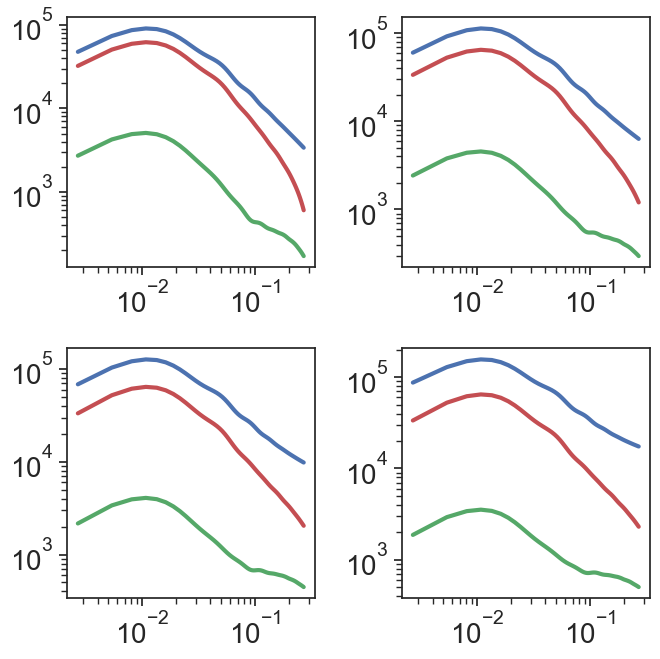

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(7,7))

for i,z in enumerate(['1.', '1.2', '1.4', '1.65']):
    ix = int(np.floor(i/2))
    iy = i%2
    axs[ix,iy].loglog(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk0'], c='b')
    axs[ix,iy].loglog(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk2'], c='r')
    axs[ix,iy].loglog(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk4'], c='g')

plt.tight_layout()

In [19]:
from cloelite.masking import masking

obs_spec_reader = reader.ObsSpecReader('../../cloelite/input/observable_specifications.yaml')
obs_spec = obs_spec_reader.get_full_config()

mask = masking.Masking(data, obs_spec)

In [20]:
redshifts = [float(x) for x in data_reader.data['GCspectro']['redshifts']]
nbar = np.array([2.042611E-03, 1.02876011E-03, 0.58531983E-03, 0.313402E-03]) * 0.67**3

theory_vec = []
for i,z in enumerate(redshifts):
    parameters = params_reader.get_section('cosmology') | params_reader.get_section('GCsp.theory', i) | params_reader.get_section('GCsp.systematics', i)
    parameters['z'] = z
    #parameters_comet = transform_dict(parameters)
    #parameters_comet_fid = deepcopy(parameters_comet)
    #mps_spectro.set_fiducial_cosmology_comet(parameters_comet_fid)
    #mps_spectro.comet_inst.define_nbar(nbar=nbar[i])
    mps_spectro.set_number_density(nbar=nbar[i])
    #mps = mps_spectro.power_multipoles(k=k, parameters=parameters_comet)
    mps_1 = mps_spectro.power_multipoles(k=data['GCspectro'][data_reader.data['GCspectro']['redshifts'][i]]['k'], parameters=parameters, ells=[0,2,4])
    for ell in [0,2,4]:
        theory_vec = np.concatenate((theory_vec, mps_1[f'ell{ell}']))

In [21]:
data_vec_masked = mask.get_masked_data_vector_GCspectro()
theory_vec_masked = mask.get_masked_theory_vector_GCspectro(theory_vec)

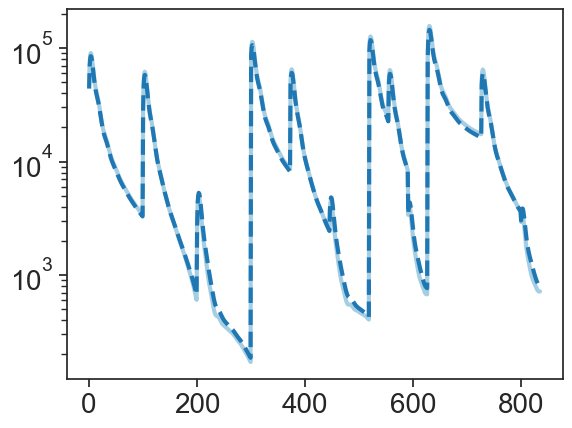

In [22]:
plt.semilogy(abs(data_vec_masked))
plt.semilogy(abs(theory_vec_masked), ls='--')

In [23]:
cosmo_keys = {}
cosmo_comm = {}

# Cosmology
# IST:Forecast cosmological model
# Customize at wish... Default is Flaghip cosmology

#COSMO_ID
cosmo_keys["COSMO_ID"] = "LCDM"
cosmo_comm["COSMO_ID"] = "Identifier for the cosmology used"

#Matter energy density
cosmo_keys["OMEGA_M"] = 0.319
cosmo_comm["OMEGA_M"] = "Matter energy density"

#Radiation energy density
cosmo_keys["OMEGA_R"] = 0.0
cosmo_comm["OMEGA_R"] = "Radiation energy density"

#Baryon energy density
cosmo_keys["OMEGA_B"] = 0.049
cosmo_comm["OMEGA_B"] = "Baryon energy density"

#Vacuum energy density
cosmo_keys["OMEGA_V"] = 0.681
cosmo_comm["OMEGA_V"] = "Vacuum energy density"

#Curvature energy density
cosmo_keys["OMEGA_K"] = 0.0
cosmo_comm["OMEGA_K"] = "Curvature energy density"

#Hubble parameter in 100 Km/s/(Mpc/h)
cosmo_keys["HUBBLE"] = 0.67
cosmo_comm["HUBBLE"] = "Hubble parameter in 100 Km/s/(Mpc/h)"

#Scalar index of primordial perturbations
cosmo_keys["INDEX_N"] = 0.96
cosmo_comm["INDEX_N"] = "Scalar index of primordial perturbations"

#Mass dispersion on 8 Mpc/h sphere
cosmo_keys["SIGMA_8"] = 0.8155
cosmo_comm["SIGMA_8"] = "Mass dispersion on 8 Mpc/h sphere"

#Dark energy equation of state
cosmo_keys["W_STATE"] = -1
cosmo_comm["W_STATE"] = "Dark energy equation of state"

#Effective number of relativistic species
cosmo_keys["N_EFF"] = 3.046
cosmo_comm["N_EFF"] = "Effective number of relativistic species"

#CMB temperature
cosmo_keys["T_CMB"] = 2.726
cosmo_comm["T_CMB"] = "CMB temperature"

def add_cosmo_keywords(hdu):
        
    for key in cosmo_keys:
        hdu.header[key] = cosmo_keys[key]
        hdu.header.comments[key] = cosmo_comm[key]

In [24]:
from astropy.io import fits

# Looping over the redshift
for i,z in enumerate(['1.', '1.2', '1.4', '1.65']):

    k, pk0, pk2, pk4 = np.loadtxt(f'/Users/pezzotta/Chiara/data/power_comet_EFT_z{z}_nosyst_DR3.txt', unpack=True, usecols=(0,1,3,5))
    nk = len(k)
    cov = np.loadtxt(f'/Users/pezzotta/Chiara/data/cov_comet_EFT_z{z}_nosyst_DR3.txt')
    cov00 = np.diag(cov[:nk,:nk])
    cov02 = np.diag(cov[:nk,nk:2*nk])
    cov04 = np.diag(cov[:nk,2*nk:])
    cov22 = np.diag(cov[nk:2*nk,nk:2*nk])
    cov24 = np.diag(cov[nk:2*nk,2*nk:])
    cov44 = np.diag(cov[2*nk:,2*nk:])
    
    l1, l2, k1, k2, cov = [], [], [], [], []
    
    # Build the arrays for the two multipole indeces, the two k values,
    # and the value of the covariance for those values
    for _l1 in [0, 2, 4]:
        for i, _k1 in enumerate(k):
            for _l2 in [0, 2, 4]:
                for j, _k2 in enumerate(k):
                    l1.append(_l1)
                    l2.append(_l2)
                    k1.append(_k1)
                    k2.append(_k2)
                    if i==j:
                        # Try-except cluase to accomodate both cases, e.g. 0-2, 2-0
                        try:
                            cov.append(globals()['cov%d%d'%(_l1,_l2)][i])
                        except KeyError:
                            cov.append(globals()['cov%d%d'%(_l2,_l1)][i])
                    else:
                        cov.append(0)
    
    # Opening fits file to store the data vectors
    hdu_list = fits.HDUList()
    
    # Defining columns to be added to the SPECTRUM table extension
    col_k = fits.Column(name="K", format="D", array = k)
    col_pk0 = fits.Column(name="PK0", format="D", array = pk0)
    col_pk2 = fits.Column(name="PK2", format="D", array = pk2)
    col_pk4 = fits.Column(name="PK4", format="D", array = pk4)
    col_mod = fits.Column(name="MOD", format="D", array = np.ones(len(k)))
    col_defs = fits.ColDefs([col_k, col_pk0, col_pk2, col_pk4, col_mod])
    
    # Creating the SPECTRUM table extension
    hdu = fits.BinTableHDU.from_columns(col_defs)
    hdu.name = "SPECTRUM"
    
    # Adding cosmology to header
    add_cosmo_keywords(hdu)
    
    # Appending the SPECTRUM table to the hdu_list and saving the fits file
    hdu_list.append(hdu)
    hdu_list.writeto('power_comet_z%s.fits'%(z), overwrite=True)
    
    # Opening fits file to store the covariance matrices
    hdu_list = fits.HDUList()
    
    # Defining columns to be added to the AVERAGE table extension
    col_k = fits.Column(name="SCALE_1DIM", format="D", array = k)
    col_pk0 = fits.Column(name="AVERAGE0", format="D", array = pk0)
    col_pk2 = fits.Column(name="AVERAGE2", format="D", array = pk2)
    col_pk4 = fits.Column(name="AVERAGE4", format="D", array = pk4)
    col_defs = fits.ColDefs([col_k, col_pk0, col_pk2, col_pk4])
    
    # Creating the AVERAGE table extension
    hdu = fits.BinTableHDU.from_columns(col_defs)
    hdu.name = "AVERAGE"
    
    # Adding cosmology to header
    add_cosmo_keywords(hdu)
    
    # Appending the AVERAGE table to the hdu_list
    hdu_list.append(hdu)
    
    # Defining columns to be added to the COVARIANCE table extension
    col_k1 = fits.Column(name="SCALE_1DIM-I", format="D", array = k1)
    col_l1 = fits.Column(name="MULTIPOLE-I", format="D", array = l1)
    col_k2 = fits.Column(name="SCALE_1DIM-J", format="D", array = k2)
    col_l2 = fits.Column(name="MULTIPOLE-J", format="D", array = l2)
    col_cov = fits.Column(name="COVARIANCE", format="D", array = cov)
    col_defs = fits.ColDefs([col_k1, col_l1, col_k2, col_l2, col_cov])
    
    # Creating the COVARIANCE table extension
    hdu = fits.BinTableHDU.from_columns(col_defs)
    hdu.name = "COVARIANCE"

    # Adding cosmology to header
    add_cosmo_keywords(hdu)
    
    # Appending the COVARIANCE table to the hdu_list and saving the fits file
    hdu_list.append(hdu)
    hdu_list.writeto('cov_power_comet_z%s.fits'%(z), overwrite=True)

In [25]:
from cloelite.likelihood.loglike import EuclidLikelihood

euclike = EuclidLikelihood('../../cloelite/input/data.yaml',
                           '../../cloelite/input/observable_specifications.yaml',
                           '../../cloelite/input/parameters.yaml')

Note: redshifts have been re-sorted (earliest first)


In [26]:
euclike.loglike({'H0':67.0, 'As':2.1e-9, 'omch2':0.121203})

-0.4852165107544459

In [4]:
import nautilus
prior = euclike.get_prior()
sampler = nautilus.Sampler(prior, euclike.loglike, n_live=300)
sampler.run(verbose=True, discard_exploration=True)
log_z = sampler.evidence()
points, log_w, log_l = sampler.posterior()
np.save('chain.npy', np.c_[log_w, log_l, points])

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 22400    | N/A    | 10004 | -16.57   


In [23]:
from getdist import plots, MCSamples
import matplotlib.pyplot as plt

In [24]:
filename = 'chain.npy'
sample = np.load(filename)
data = sample[:,range(2,5)]
weights = np.exp(sample[:,0])

samples={}
samples['1'] = \
    MCSamples(ranges={'h':[0.6,0.8], 'omch2':[0.085,0.15], 'As':[1.5e-9, 2.7e-9]}, samples=data, weights=weights,
              names=['h', 'omch2', 'As'],
              labels=[r'h', r'\omega_{\rm c}', r'A_{\rm s}'],
              label='')

Removed no burn in


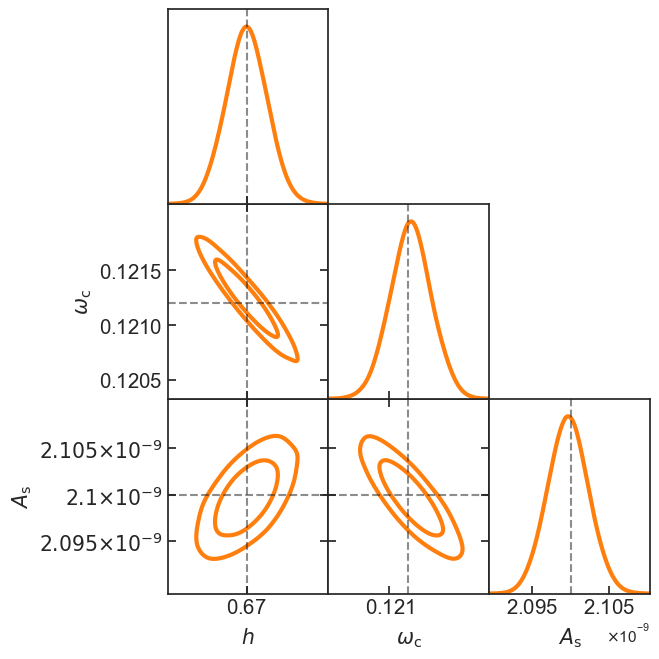

In [25]:
g = plots.getSubplotPlotter(width_inch=7)
g.settings.axes_fontsize = 17
g.settings.lab_fontsize = 17
g.settings.lw_contour = 2
g.settings.legend_fontsize = 15

colors = ['#ff7f0e']

g.triangle_plot([samples[key] for key in samples.keys()],
                colors=colors, contour_colors=colors,
                line_args=[{'lw':3, 'color':x} for x in colors],
                legend_ncol=1, legend_loc='upper right', legend_fontsize=13,
                filled=[False,False,False,False,True], labelspacing=0.1, contour_lws=[3,3,3,3])

for ax in g.subplots[0:,0]:
    ax.axvline(0.67, color='k', lw=1.5, ls='--', alpha=0.5)
for ax in g.subplots[1:,1]:
    ax.axvline(0.27*0.67**2, color='k', lw=1.5, ls='--', alpha=0.5)
for ax in g.subplots[2:,2]:
    ax.axvline(2.1e-9, color='k', lw=1.5, ls='--', alpha=0.5)
for ax in g.subplots[1,:1]:
    ax.axhline(0.27*0.67**2, color='k', lw=1.5, ls='--', alpha=0.5)
for ax in g.subplots[2,:2]:
    ax.axhline(2.1e-9, color='k', lw=1.5, ls='--', alpha=0.5)

In [26]:
data_reader.read_GCspectro_mixing_matrix()
mixing_matrix_dict = data_reader.mixing_matrix_dict

mps_spectro = spectro.LegendreMultipolesComet(
    linear_perturbations=linear_perturbations,
    background_fiducial=background_fiducial,
    mixing_matrix_dict=mixing_matrix_dict['1.'])

mps_spectro.set_number_density(nbar=1e-4)

In [27]:
mps = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])
mps_convolved = mps_spectro.convolved_power_multipoles(parameters=parameters)

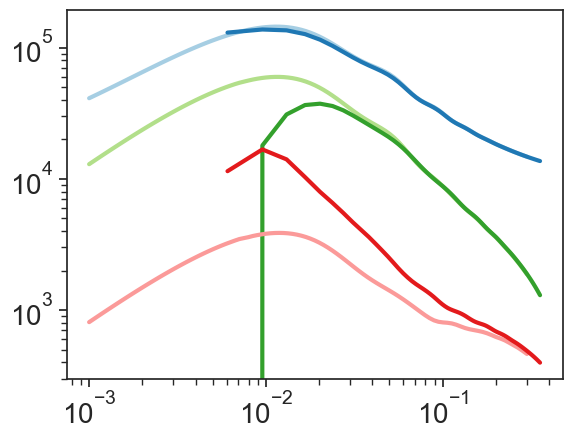

In [28]:
plt.loglog(k, mps['ell0'])
plt.loglog(mps_convolved['k'], mps_convolved['ell0'])
plt.loglog(k, mps['ell2'])
plt.loglog(mps_convolved['k'], mps_convolved['ell2'])
plt.loglog(k, mps['ell4'])
plt.loglog(mps_convolved['k'], mps_convolved['ell4'])